In [ ]:
!pip install datasets pyarrow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 485.4/485.4 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 18.9 MB/s eta 0:00:00


In [ ]:
from datasets import load_dataset

dataset = load_dataset("MultimodalUniverse/legacysurvey", split="train", streaming=True)

dataset_iter = iter(dataset)

first_500 = [next(dataset_iter) for _ in range(500)]

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/19.2k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/165 [00:00<?, ?it/s]

In [ ]:
print(first_500[0])

{'image': {'band': ['des-g', 'des-r', 'des-i', 'des-z'], 'flux': [[[0.0007380799506790936, -0.00016050622798502445, 0.0003010692889802158, 0.0009010408539324999, -0.0005762063665315509, -0.002971604699268937, 0.0027692108415067196, 0.0013593563344329596, -0.001967120449990034, -0.0016669273609295487, -0.0008193973917514086, 0.00151748675853014, 0.00043023674516007304, 0.0005182579625397921, 0.002291673794388771, -0.0011070449836552143, -0.0017752716084942222, 0.0026381714269518852, 0.0010797434952110052, -0.0020202258601784706, -0.001806977204978466, 0.000562246423214674, 0.0005059128161519766, -0.001393625745549798, -0.0007378564914688468, -2.5792658561840653e-05, 0.0003319118986837566, 0.0015727252466604114, -0.001676557818427682, 0.00042274227598682046, -0.001041117124259472, -0.0007270867936313152, 0.0012817319948226213, -0.001600002753548324, 0.0003819463890977204, -0.0035971947945654392, 0.0014767233515158296, -0.0010808437364175916, 0.0021874832455068827, 0.003161314409226179, -

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

IMG_SIZE = 64

def preprocess_image(example):
    """Extract and process flux image data correctly."""
    flux_array = np.array(example["image"]["flux"])  # extract flux values
    flux_array = np.mean(flux_array, axis=0)  # average across bands (convert to grayscale)

    flux_resized = tf.image.resize(tf.convert_to_tensor(flux_array)[..., None], (IMG_SIZE, IMG_SIZE)).numpy()

    # normalize to [0, 1]
    flux_resized = (flux_resized - np.min(flux_resized)) / (np.max(flux_resized) - np.min(flux_resized))

    return flux_resized

# convert first 500 images
train_images = np.array([preprocess_image(img) for img in first_500])

print(f"Dataset shape: {train_images.shape}")

Dataset shape: (500, 64, 64, 1)


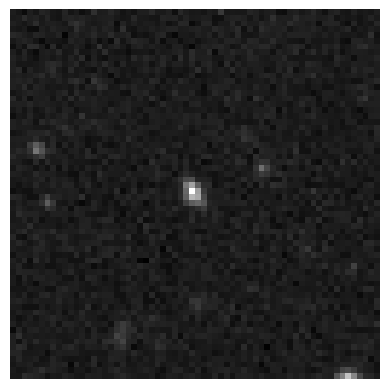

In [ ]:
plt.imshow(train_images[0], cmap="gray")
plt.axis("off")
plt.show()

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
import tensorflow.keras.backend as K
import matplotlib.pyplot as plt
from PIL import Image
import io
import datasets

In [ ]:
dataset = load_dataset("MultimodalUniverse/legacysurvey", split="train", streaming=True)

dataset_iter = iter(dataset)

first_500 = [next(dataset_iter) for _ in range(500)]

IMG_SIZE = 64

def preprocess_image(example):
    """Convert multimodal dataset format to a NumPy image array."""
    flux = np.array(example["image"]["flux"])  # extract flux data

    image = flux[0]
    image = np.clip(image, 0, 1)  # normalize to range [0,1]
    image = Image.fromarray((image * 255).astype(np.uint8))  # convert to PIL Image
    image = image.resize((IMG_SIZE, IMG_SIZE))  # resize to 64x64
    image = np.array(image) / 255.0  # normalize pixel values to [0,1]

    return image

train_images = np.array([preprocess_image(img) for img in first_500])

train_images = np.expand_dims(train_images, axis=-1)

print(f"Dataset shape: {train_images.shape}"))

Resolving data files:   0%|          | 0/165 [00:00<?, ?it/s]

Dataset shape: (500, 64, 64, 1)


In [ ]:
class Sampling(layers.Layer):
    """Reparameterization trick to sample from N(mu, var)"""
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, Flatten, Dense, Lambda, Reshape, Conv2DTranspose
from tensorflow.keras.models import Model
import tensorflow.keras.backend as K

LATENT_DIM = 16

# Encoder
def build_encoder():
    input_img = Input(shape=(64, 64, 1))

    x = Conv2D(32, (3,3), activation="relu", strides=2, padding="same")(input_img)
    x = Conv2D(64, (3,3), activation="relu", strides=2, padding="same")(x)
    x = Flatten()(x)
    x = Dense(128, activation="relu")(x)

    # Latent space variables
    z_mean = Dense(LATENT_DIM, name="z_mean")(x)
    z_log_var = Dense(LATENT_DIM, name="z_log_var")(x)

    # Reparameterization trick
    def sampling(args):
        z_mean, z_log_var = args
        epsilon = K.random_normal(shape=(K.shape(z_mean)[0], LATENT_DIM), mean=0., stddev=1.0)
        return z_mean + K.exp(0.5 * z_log_var) * epsilon

    z = Lambda(sampling, output_shape=(LATENT_DIM,), name="z")([z_mean, z_log_var])

    encoder = Model(input_img, [z_mean, z_log_var, z], name="Encoder")
    return encoder

encoder = build_encoder()
encoder.summary()

Model: "Encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 64, 64, 1)      │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 32, 32, 32)     │            320 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 16, 16, 64)     │         18,496 │ conv2d[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten (Flatten)         │ (None, 16384)          │              0 │ conv2d_1[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense (Dense)             │ (None, 128)            │      2,097,280 │ flatten[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ z_mean (Dense)            │ (None, 16)             │          2,064 │ dense[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ z_log_var (Dense)         │ (None, 16)             │          2,064 │ dense[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ z (Lambda)                │ (None, 16)             │              0 │ z_mean[0][0],          │
│                           │                        │                │ z_log_var[0][0]        │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 2,120,224 (8.09 MB)

 Trainable params: 2,120,224 (8.09 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Decoder network
def build_decoder():
    latent_inputs = Input(shape=(LATENT_DIM,), name="z_sampling")

    x = Dense(16 * 16 * 64, activation="relu")(latent_inputs)
    x = Reshape((16, 16, 64))(x)
    x = Conv2DTranspose(64, (3,3), activation="relu", strides=2, padding="same")(x)
    x = Conv2DTranspose(32, (3,3), activation="relu", strides=2, padding="same")(x)
    x = Conv2DTranspose(1, (3,3), activation="sigmoid", padding="same")(x)  # Output grayscale image

    decoder = Model(latent_inputs, x, name="Decoder")
    return decoder

decoder = build_decoder()
decoder.summary()

Model: "Decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ z_sampling (InputLayer)              │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16384)               │         278,528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape (Reshape)                    │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose (Conv2DTranspose)   │ (None, 32, 32, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose_1 (Conv2DTranspose) │ (None, 64, 64, 32)          │          18,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose_2 (Conv2DTranspose) │ (None, 64, 64, 1)           │             289 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 334,209 (1.27 MB)

 Trainable params: 334,209 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.losses import binary_crossentropy

class VAE(tf.keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstructed = self.decoder(z)
        return reconstructed

vae = VAE(encoder, decoder)

In [ ]:
def vae_loss(y_true, y_pred):
    """Custom VAE loss combining reconstruction loss and KL divergence."""
    reconstruction_loss = binary_crossentropy(K.flatten(y_true), K.flatten(y_pred))
    reconstruction_loss *= 64 * 64

    # KL Divergence
    z_mean, z_log_var, _ = encoder(y_true)
    kl_loss = -0.5 * K.sum(1 + z_log_var - K.square(z_mean) - K.exp(z_log_var), axis=-1)

    return K.mean(reconstruction_loss + kl_loss)

vae.compile(optimizer="adam", loss=vae_loss)

In [ ]:
vae.fit(train_images, train_images, epochs=50, batch_size=32)

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 213ms/step - loss: 2429.2019
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 97.0120 
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 42.0876
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 45.0935
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 35.8419
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 40.0019
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 32.1565
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 29.6481
Epoch 9/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 28.1948
Epoch 10/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 25.5309
Epoch 11/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 28.6105
Epoch 12/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 27.8417
Epoch 13/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 23.5582
Epoch 14/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 27.9025
Epoch 15/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - lo

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 950ms/step


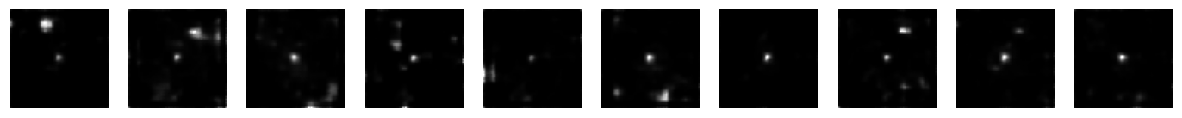

In [ ]:
import numpy as np

def generate_images(decoder, num_images=5):
    random_latent_vectors = np.random.normal(size=(num_images, LATENT_DIM))
    generated_images = decoder.predict(random_latent_vectors)

    fig, axes = plt.subplots(1, num_images, figsize=(15, 3))
    for i, img in enumerate(generated_images):
        axes[i].imshow(img.squeeze(), cmap="gray")
        axes[i].axis("off")
    plt.show()

generate_images(decoder, num_images=10)

In [ ]:
import numpy as np

# Compute reconstruction loss (MSE) between original and reconstructed images
def compute_reconstruction_loss(vae, dataset, num_samples=100):
    dataset_iter = iter(dataset)
    losses = []

    for _ in range(num_samples):
        example = next(dataset_iter)
        original_image = preprocess_image(example)
        original_image = np.expand_dims(original_image, axis=0)

        reconstructed_image = vae(original_image)
        loss = np.mean((original_image - reconstructed_image.numpy())**2)  # MSE

        losses.append(loss)

    return np.mean(losses)

reconstruction_loss = compute_reconstruction_loss(vae, first_500[:500])
print(f"Average Reconstruction Loss: {reconstruction_loss}")

Average Reconstruction Loss: 0.00048354564934165753
